# PJM Electricity Load Forecasting - Exploratory Data Analysis (EDA)

Dataset: PJME_hourly.csv  
Goal: Explore hourly load patterns and data quality for forecasting.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("PJME_hourly.csv")
df.head()


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [5]:
print("Shape:", df.shape)
df.info()
df.describe()


Shape: (145366, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [6]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").set_index("Datetime")
df.head()


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [7]:
df.isna().sum()


,0
PJME_MW,0


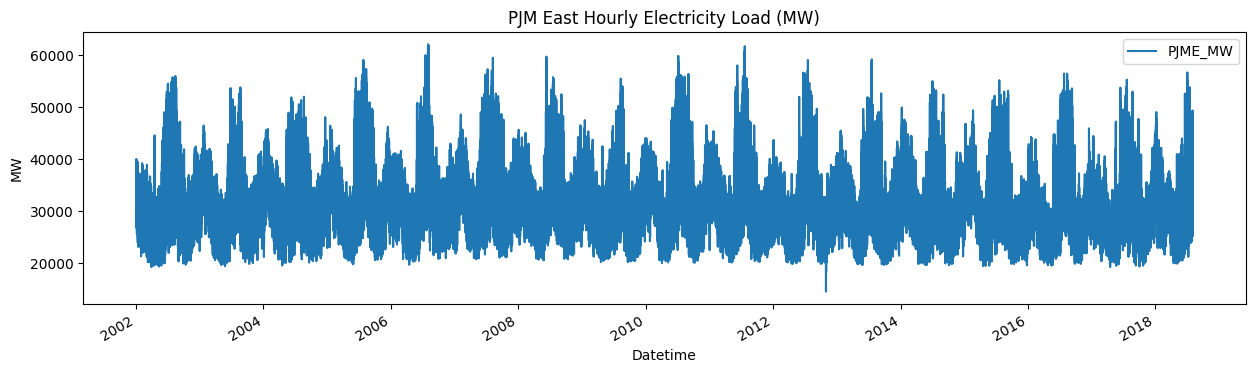

In [8]:
df.plot(figsize=(15,4))
plt.title("PJM East Hourly Electricity Load (MW)")
plt.ylabel("MW")
plt.show()


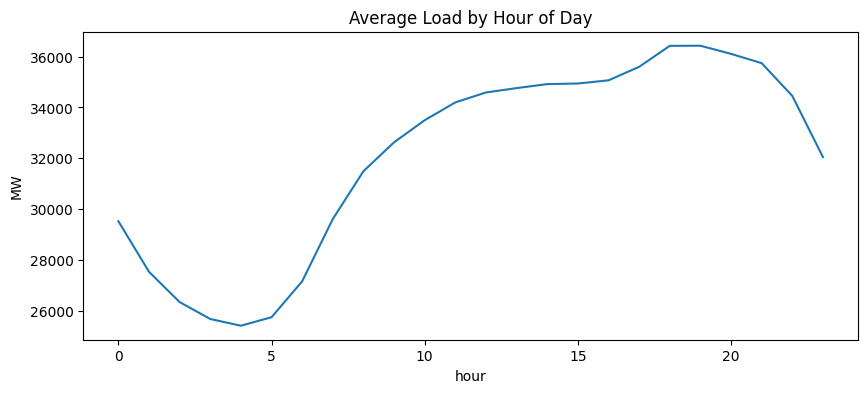

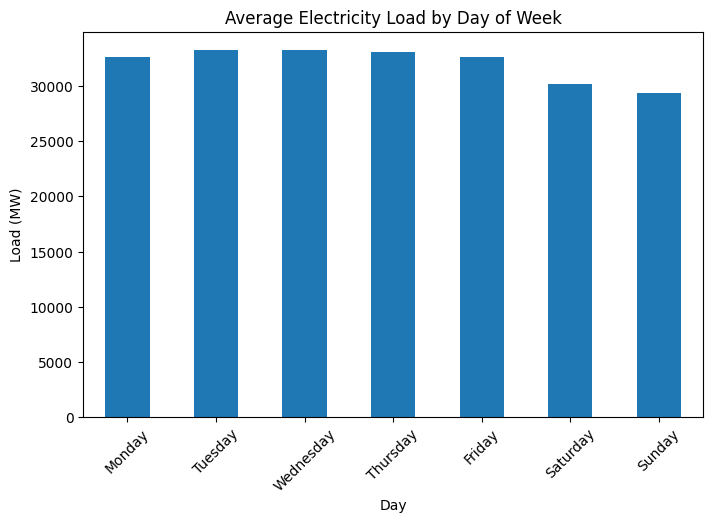

In [13]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek

df.groupby("hour")["PJME_MW"].mean().plot(figsize=(10,4))
plt.title("Average Load by Hour of Day")
plt.ylabel("MW")
plt.show()

df['day_name'] = df.index.day_name()
df['month_name'] = df.index.month_name()

day_avg = df.groupby('day_name')['PJME_MW'].mean()

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_avg = day_avg.reindex(order)

day_avg.plot(kind='bar', figsize=(8,5))
plt.title("Average Electricity Load by Day of Week")
plt.xlabel("Day")
plt.ylabel("Load (MW)")
plt.xticks(rotation=45)
plt.show()

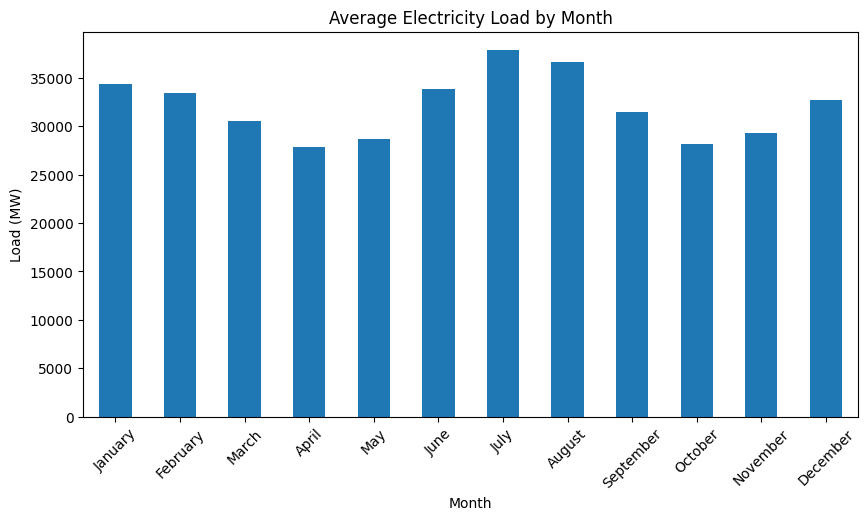

In [12]:
month_avg = df.groupby('month_name')['PJME_MW'].mean()

order = ['January','February','March','April','May','June',
         'July','August','September','October','November','December']

month_avg = month_avg.reindex(order)

month_avg.plot(kind='bar', figsize=(10,5))
plt.title("Average Electricity Load by Month")
plt.xlabel("Month")
plt.ylabel("Load (MW)")
plt.xticks(rotation=45)
plt.show()

### EDA Insights

- The electricity load shows repeating seasonal patterns over time.
- Load is lowest in the early morning and highest in the evening hours.
- Weekday demand is higher than weekend demand.
- Monthly average load varies across the year, showing seasonality.